In [20]:
import os
import tempfile
import subprocess
import numpy as np

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

AM_EXE = os.path.join(BASE, "am.exe")

DATASET_DIR = os.path.join(BASE, "NN_DATASET")

X = np.load(os.path.join(DATASET_DIR, "X.npy"))

print("X shape:", X.shape)

# ==========================================================
# METADATA
# ==========================================================

meta = np.load(
    os.path.join(
        BASE,
        "ERA5_DATABASE",
        "site_264967_802413",
        "metadata_pressure.npz"
    )
)

levels = meta["pressure_levels"] * 100.0

P_STEP = 50.0
T_STEP = 1.0
Q_STEP = 2e-4

epsilon = 0.622

# ==========================================================
# DECODE ATMOSPHERE
# ==========================================================

def decode(row):

    insert = int(row[0])

    ps = row[1] * P_STEP
    ts = row[2] * T_STEP
    vmr_surface = row[3] * Q_STEP

    temp = row[4:17].astype(np.float32) * T_STEP
    vmr  = row[17:30].astype(np.float32) * Q_STEP

    P = np.insert(levels, insert, ps)
    T = np.insert(temp,   insert, ts)
    V = np.insert(vmr,    insert, vmr_surface)

    return insert, P, T, V

# ==========================================================
# BUILD AMC FILE
# ==========================================================

def make_amc(P, T, V, insert):

    lines = []

    lines.append("f 2 GHz 14 GHz 0.1 GHz")
    lines.append("output f GHz tx Tb K")
    lines.append("T0 2.7 K")
    lines.append("za 0 deg")
    lines.append("")

    P = P[insert:][::-1]
    T = T[insert:][::-1]
    V = V[insert:][::-1]

    for p, t, q in zip(P, T, V):

        lines.append("layer")
        lines.append(f"Pbase {p:.1f} Pa")
        lines.append(f"Tbase {t:.3f} K")
        lines.append("column dry_air hydrostatic")
        lines.append(f"column h2o vmr {q:.8e}")
        lines.append("")

    return "\n".join(lines)

# ==========================================================
# RUN AM
# ==========================================================

def run_am(row):

    insert, P, T, V = decode(row)

    with tempfile.TemporaryDirectory() as d:

        amc = os.path.join(d, "temp.amc")

        with open(amc, "w") as f:
            f.write(make_amc(P, T, V, insert))

        result = subprocess.run(
            [AM_EXE, amc],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        freq = []
        tau = []
        tb = []

        for line in result.stdout.splitlines():

            line = line.strip()

            if not line:
                continue

            if line[0] in "#!?":
                continue

            s = line.split()

            if len(s) < 3:
                continue

            try:
                freq.append(float(s[0]))
                tau.append(float(s[1]))
                tb.append(float(s[2]))
            except ValueError:
                pass

    return (
        np.asarray(freq, dtype=np.float32),
        np.asarray(tau, dtype=np.float32),
        np.asarray(tb, dtype=np.float32),
    )

# ==========================================================
# QUICK SANITY CHECK
# ==========================================================

f, tau, tb = run_am(X[0])

print("Frequency :", f.shape)
print("Tau       :", tau.shape)
print("Tb        :", tb.shape)

X shape: (50000, 30)
Frequency : (121,)
Tau       : (121,)
Tb        : (121,)


In [21]:
import os
import numpy as np

# ==========================================================
# Resume support
# ==========================================================

tb_file = os.path.join(DATASET_DIR, "Tb.npy")
tau_file = os.path.join(DATASET_DIR, "Tau.npy")
freq_file = os.path.join(DATASET_DIR, "Frequency.npy")

N = len(X)

# ----------------------------------------------------------
# Resume if files already exist
# ----------------------------------------------------------

if os.path.exists(tb_file):

    Tb = list(np.load(tb_file))
    Tau = list(np.load(tau_file))
    freq = np.load(freq_file)

    start = len(Tb)

    print("="*60)
    print("Resuming previous run")
    print(f"Already completed : {start}/{N}")
    print("="*60)

else:

    Tb = []
    Tau = []
    freq = None
    start = 0

    print("="*60)
    print("Starting new run")
    print("="*60)

# ==========================================================
# Generate spectra
# ==========================================================

SAVE_EVERY = 100

for i in range(start, N):

    f, tau, tb = run_am(X[i])

    if freq is None:
        freq = f

    Tb.append(tb)
    Tau.append(tau)

    # --------------------------------------------
    # Progress
    # --------------------------------------------

    if (i + 1) % 10 == 0:

        print(
            f"\r{i+1}/{N}",
            end="",
            flush=True
        )

    # --------------------------------------------
    # Checkpoint
    # --------------------------------------------

    if (i + 1) % SAVE_EVERY == 0:

        np.save(tb_file, np.asarray(Tb, dtype=np.float32))
        np.save(tau_file, np.asarray(Tau, dtype=np.float32))
        np.save(freq_file, freq)

        print()
        print("="*60)
        print(f"Checkpoint saved ({i+1}/{N})")
        print("="*60)

# ==========================================================
# Final save
# ==========================================================

Tb = np.asarray(Tb, dtype=np.float32)
Tau = np.asarray(Tau, dtype=np.float32)

np.save(tb_file, Tb)
np.save(tau_file, Tau)
np.save(freq_file, freq)

print()
print("="*60)
print("Finished.")
print("="*60)
print("Tb   :", Tb.shape)
print("Tau  :", Tau.shape)
print("Freq :", freq.shape)

Resuming previous run
Already completed : 6000/50000
6100/50000
Checkpoint saved (6100/50000)
6200/50000
Checkpoint saved (6200/50000)
6300/50000
Checkpoint saved (6300/50000)
6400/50000
Checkpoint saved (6400/50000)
6500/50000
Checkpoint saved (6500/50000)
6600/50000
Checkpoint saved (6600/50000)
6700/50000
Checkpoint saved (6700/50000)
6800/50000
Checkpoint saved (6800/50000)
6900/50000
Checkpoint saved (6900/50000)
7000/50000
Checkpoint saved (7000/50000)
7100/50000
Checkpoint saved (7100/50000)
7200/50000
Checkpoint saved (7200/50000)
7300/50000
Checkpoint saved (7300/50000)
7400/50000
Checkpoint saved (7400/50000)
7500/50000
Checkpoint saved (7500/50000)
7600/50000
Checkpoint saved (7600/50000)
7700/50000
Checkpoint saved (7700/50000)
7800/50000
Checkpoint saved (7800/50000)
7900/50000
Checkpoint saved (7900/50000)
8000/50000
Checkpoint saved (8000/50000)
8100/50000
Checkpoint saved (8100/50000)
8200/50000
Checkpoint saved (8200/50000)
8300/50000
Checkpoint saved (8300/50000)
8400

KeyboardInterrupt: 

In [22]:
import os
import numpy as np
import torch

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

DATASET_DIR = os.path.join(BASE, "NN_DATASET")
MODEL_DIR = os.path.join(BASE, "NN_MODEL")

os.makedirs(MODEL_DIR, exist_ok=True)

# ==========================================================
# LOAD DATA
# ==========================================================

X = np.load(
    os.path.join(DATASET_DIR, "X.npy")
).astype(np.float32)

Y = np.load(
    os.path.join(DATASET_DIR, "Tb.npy")
).astype(np.float32)
# Keep only atmospheres that have AM outputs
X = X[:len(Y)]

print(X.shape)
print(Y.shape)
freq = np.load(
    os.path.join(DATASET_DIR, "Frequency.npy")
)

print("="*60)
print("Dataset Loaded")
print("="*60)

print("X :", X.shape)
print("Y :", Y.shape)
print("Frequency :", freq.shape)

(10100, 30)
(10100, 121)
Dataset Loaded
X : (10100, 30)
Y : (10100, 121)
Frequency : (121,)


In [23]:
import os
import numpy as np

# ==========================================================
# NORMALIZATION
# ==========================================================

# -------- Input normalization --------

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)

# Prevent division by zero
X_std[X_std == 0] = 1.0

X_norm = (X - X_mean) / X_std

# -------- Output normalization --------

Y_mean = Y.mean(axis=0)
Y_std  = Y.std(axis=0)

Y_std[Y_std == 0] = 1.0

Y_norm = (Y - Y_mean) / Y_std

# ==========================================================
# SAVE NORMALIZATION
# ==========================================================

np.save(os.path.join(MODEL_DIR, "X_mean.npy"), X_mean)
np.save(os.path.join(MODEL_DIR, "X_std.npy"), X_std)

np.save(os.path.join(MODEL_DIR, "Y_mean.npy"), Y_mean)
np.save(os.path.join(MODEL_DIR, "Y_std.npy"), Y_std)

# ==========================================================
# SANITY CHECK
# ==========================================================

print("=" * 60)
print("Normalization Complete")
print("=" * 60)

print()

print("Input")
print("Mean (avg):", X_norm.mean())
print("Std  (avg):", X_norm.std())

print()

print("Output")
print("Mean (avg):", Y_norm.mean())
print("Std  (avg):", Y_norm.std())

print()

print("Normalization files saved to:")
print(MODEL_DIR)

Normalization Complete

Input
Mean (avg): 1.7731418e-06
Std  (avg): 0.94868535

Output
Mean (avg): -6.380324e-06
Std  (avg): 1.0000001

Normalization files saved to:
C:\Users\Darkrai\Projects\iitk proj\NN_MODEL


In [24]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# ==========================================================
# SETTINGS
# ==========================================================

VALIDATION_FRACTION = 0.20
BATCH_SIZE = 256
SEED = 42

# ==========================================================
# TRAIN / VALIDATION SPLIT
# ==========================================================

rng = np.random.default_rng(SEED)

indices = np.arange(len(X_norm))
rng.shuffle(indices)

split = int((1.0 - VALIDATION_FRACTION) * len(indices))

train_idx = indices[:split]
val_idx = indices[split:]

# Save validation indices for reproducibility
np.save(
    os.path.join(MODEL_DIR, "validation_indices.npy"),
    val_idx
)

# ==========================================================
# SPLIT DATA
# ==========================================================

X_train = X_norm[train_idx]
Y_train = Y_norm[train_idx]

X_val = X_norm[val_idx]
Y_val = Y_norm[val_idx]

print("=" * 60)
print("Dataset Split")
print("=" * 60)

print(f"Training samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")

# ==========================================================
# CONVERT TO TORCH
# ==========================================================

X_train = torch.from_numpy(X_train).float()
Y_train = torch.from_numpy(Y_train).float()

X_val = torch.from_numpy(X_val).float()
Y_val = torch.from_numpy(Y_val).float()

# ==========================================================
# DATASETS
# ==========================================================

train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

# ==========================================================
# DATALOADERS
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print()
print("Train batches :", len(train_loader))
print("Val batches   :", len(val_loader))

Dataset Split
Training samples   : 8,080
Validation samples : 2,020

Train batches : 32
Val batches   : 8


In [25]:
import torch
import torch.nn as nn

# ==========================================================
# DEVICE
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ==========================================================
# SURROGATE NETWORK
# ==========================================================

class Surrogate(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(30, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 121)

        )

    def forward(self, x):

        return self.net(x)

# ==========================================================
# CREATE MODEL
# ==========================================================

model = Surrogate().to(device)

# ==========================================================
# LOSS
# ==========================================================

criterion = nn.MSELoss()

# ==========================================================
# OPTIMIZER
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# ==========================================================
# OPTIONAL LR SCHEDULER
# ==========================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    verbose=True
)

# ==========================================================
# MODEL SUMMARY
# ==========================================================

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print(model)
print("="*60)

print(f"Parameters : {total:,}")
print(f"Trainable  : {trainable:,}")

Device: cuda
Surrogate(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=121, bias=True)
  )
)
Parameters : 151,289
Trainable  : 151,289


c:\Users\Darkrai\Projects\torch_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [26]:
import os
import numpy as np
import torch

# ==========================================================
# TRAINING SETTINGS
# ==========================================================

EPOCHS = 100

best_val = np.inf

train_history = []
val_history = []

# ==========================================================
# TRAINING LOOP
# ==========================================================

for epoch in range(EPOCHS):

    # ------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            pred = model(xb)

            loss = criterion(pred, yb)

            running_loss += loss.item() * xb.size(0)

    val_loss = running_loss / len(val_loader.dataset)

    # ------------------------------------------------------
    # Scheduler
    # ------------------------------------------------------

    scheduler.step(val_loss)

    train_history.append(train_loss)
    val_history.append(val_loss)

    # ------------------------------------------------------
    # Save Best Model
    # ------------------------------------------------------

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_model.pt")
        )

    # ------------------------------------------------------
    # Progress
    # ------------------------------------------------------

    print(
        f"Epoch {epoch+1:3d} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

# ==========================================================
# SAVE LOSS HISTORY
# ==========================================================

train_history = np.asarray(train_history)
val_history = np.asarray(val_history)

np.save(
    os.path.join(MODEL_DIR, "train_loss.npy"),
    train_history
)

np.save(
    os.path.join(MODEL_DIR, "val_loss.npy"),
    val_history
)

print()
print("="*60)
print("Training Finished")
print("="*60)
print(f"Best Validation Loss : {best_val:.6f}")
print("Model saved to:")
print(os.path.join(MODEL_DIR, "best_model.pt"))

Epoch   1 | Train 0.396487 | Val 0.058200
Epoch   2 | Train 0.031924 | Val 0.018203
Epoch   3 | Train 0.015557 | Val 0.010936
Epoch   4 | Train 0.008123 | Val 0.004998
Epoch   5 | Train 0.004005 | Val 0.002873
Epoch   6 | Train 0.002401 | Val 0.002202
Epoch   7 | Train 0.001547 | Val 0.001299
Epoch   8 | Train 0.001168 | Val 0.001008
Epoch   9 | Train 0.000988 | Val 0.000952
Epoch  10 | Train 0.000808 | Val 0.000737
Epoch  11 | Train 0.000795 | Val 0.000772
Epoch  12 | Train 0.000679 | Val 0.000738
Epoch  13 | Train 0.000612 | Val 0.000669
Epoch  14 | Train 0.000559 | Val 0.000526
Epoch  15 | Train 0.000539 | Val 0.000592
Epoch  16 | Train 0.000759 | Val 0.000587
Epoch  17 | Train 0.000664 | Val 0.000424
Epoch  18 | Train 0.000403 | Val 0.000383
Epoch  19 | Train 0.000386 | Val 0.000860
Epoch  20 | Train 0.000591 | Val 0.000458
Epoch  21 | Train 0.000447 | Val 0.000499
Epoch  22 | Train 0.000437 | Val 0.000333
Epoch  23 | Train 0.000347 | Val 0.000322
Epoch  24 | Train 0.000291 | Val 0

TRAINING SUMMARY
Epochs trained        : 100
Best epoch            : 100
Final training loss   : 0.000077
Final validation loss : 0.000089

Best validation loss  : 0.000089


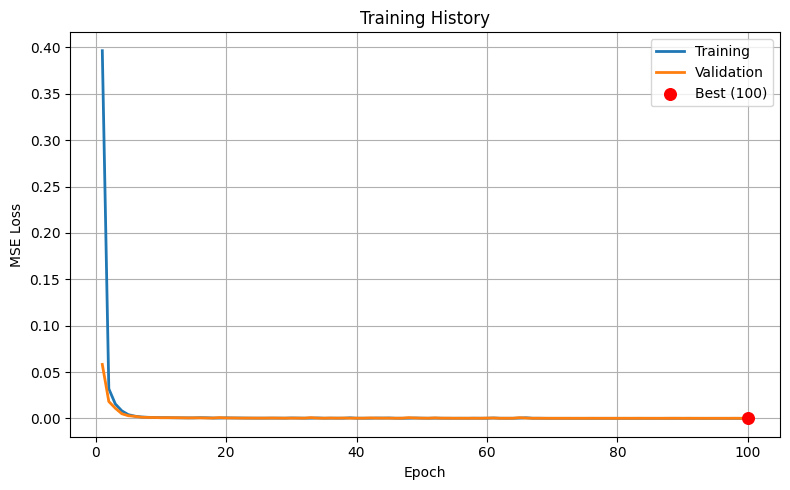

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LOAD LOSS HISTORY
# ==========================================================

train_loss = np.load(
    os.path.join(MODEL_DIR, "train_loss.npy")
)

val_loss = np.load(
    os.path.join(MODEL_DIR, "val_loss.npy")
)

epochs = np.arange(1, len(train_loss)+1)

best_epoch = np.argmin(val_loss)

# ==========================================================
# PRINT SUMMARY
# ==========================================================

print("="*60)
print("TRAINING SUMMARY")
print("="*60)

print(f"Epochs trained        : {len(train_loss)}")
print(f"Best epoch            : {best_epoch+1}")

print(f"Final training loss   : {train_loss[-1]:.6f}")
print(f"Final validation loss : {val_loss[-1]:.6f}")

print()

print(f"Best validation loss  : {val_loss[best_epoch]:.6f}")

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    train_loss,
    lw=2,
    label="Training"
)

plt.plot(
    epochs,
    val_loss,
    lw=2,
    label="Validation"
)

plt.scatter(
    epochs[best_epoch],
    val_loss[best_epoch],
    s=70,
    color="red",
    zorder=5,
    label=f"Best ({best_epoch+1})"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Training History")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [28]:
import os
import numpy as np
import torch
import torch.nn as nn

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

DATASET_DIR = os.path.join(BASE, "NN_DATASET")
MODEL_DIR   = os.path.join(BASE, "NN_MODEL")

# ==========================================================
# LOAD DATA
# ==========================================================

X = np.load(
    os.path.join(DATASET_DIR, "X.npy")
).astype(np.float32)

Y = np.load(
    os.path.join(DATASET_DIR, "Tb.npy")
).astype(np.float32)

freq = np.load(
    os.path.join(DATASET_DIR, "Frequency.npy")
)

# Only atmospheres for which AM output exists
X = X[:len(Y)]

# ==========================================================
# LOAD NORMALIZATION
# ==========================================================

X_mean = np.load(os.path.join(MODEL_DIR, "X_mean.npy"))
X_std  = np.load(os.path.join(MODEL_DIR, "X_std.npy"))

Y_mean = np.load(os.path.join(MODEL_DIR, "Y_mean.npy"))
Y_std  = np.load(os.path.join(MODEL_DIR, "Y_std.npy"))

X_std[X_std == 0] = 1
Y_std[Y_std == 0] = 1

# ==========================================================
# LOAD VALIDATION INDICES
# ==========================================================

val_idx = np.load(
    os.path.join(MODEL_DIR, "validation_indices.npy")
)

print("Validation samples :", len(val_idx))

# ==========================================================
# NORMALIZE INPUTS
# ==========================================================

X_norm = (X - X_mean) / X_std

# ==========================================================
# MODEL
# ==========================================================

class Surrogate(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(30,128),
            nn.ReLU(),

            nn.Linear(128,256),
            nn.ReLU(),

            nn.Linear(256,256),
            nn.ReLU(),

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Linear(128,121)

        )

    def forward(self,x):

        return self.net(x)

# ==========================================================
# LOAD MODEL
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = Surrogate().to(device)

model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR,"best_model.pt"),
        map_location=device
    )
)

model.eval()

print()
print("="*60)
print("Validation Notebook Ready")
print("="*60)
print("Dataset :", X.shape)
print("Targets :", Y.shape)
print("Frequency channels :", len(freq))
print("Device :", device)

Validation samples : 2020

Validation Notebook Ready
Dataset : (10100, 30)
Targets : (10100, 121)
Frequency channels : 121
Device : cuda


C:\Users\Darkrai\AppData\Local\Temp\ipykernel_21296\3021450058.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [29]:
import numpy as np
import torch

# ==========================================================
# VALIDATION INPUTS
# ==========================================================

X_val = X_norm[val_idx]
Y_val = Y[val_idx]

print("Validation set :", X_val.shape)

# ==========================================================
# PREDICT
# ==========================================================

with torch.no_grad():

    pred = model(
        torch.from_numpy(X_val)
        .float()
        .to(device)
    ).cpu().numpy()

# ==========================================================
# DENORMALIZE
# ==========================================================

pred = pred * Y_std + Y_mean

truth = Y_val.copy()

# ==========================================================
# ERRORS
# ==========================================================

error = pred - truth
abs_error = np.abs(error)

# ----------------------------------------------------------
# Per-sample metrics
# ----------------------------------------------------------

sample_mae = abs_error.mean(axis=1)

sample_rmse = np.sqrt(
    np.mean(error**2, axis=1)
)

sample_max = abs_error.max(axis=1)

# ----------------------------------------------------------
# Global metrics
# ----------------------------------------------------------

global_mae = abs_error.mean()

global_rmse = np.sqrt(
    np.mean(error**2)
)

global_max = abs_error.max()

# ----------------------------------------------------------
# Frequency-wise metrics
# ----------------------------------------------------------

freq_mae = abs_error.mean(axis=0)

freq_rmse = np.sqrt(
    np.mean(error**2, axis=0)
)

freq_max = abs_error.max(axis=0)

# ==========================================================
# PRINT
# ==========================================================

print("="*60)
print("VALIDATION RESULTS")
print("="*60)

print(f"Validation samples : {len(val_idx):,}")
print()

print(f"Global MAE         : {global_mae:.6f} K")
print(f"Global RMSE        : {global_rmse:.6f} K")
print(f"Maximum Error      : {global_max:.6f} K")

print()

print(f"Mean Sample MAE    : {sample_mae.mean():.6f} K")
print(f"Worst Sample MAE   : {sample_mae.max():.6f} K")

print()

print(f"Mean Sample RMSE   : {sample_rmse.mean():.6f} K")
print(f"Worst Sample RMSE  : {sample_rmse.max():.6f} K")

print("="*60)

Validation set : (2020, 30)
VALIDATION RESULTS
Validation samples : 2,020

Global MAE         : 0.005567 K
Global RMSE        : 0.009558 K
Maximum Error      : 0.134840 K

Mean Sample MAE    : 0.005567 K
Worst Sample MAE   : 0.038062 K

Mean Sample RMSE   : 0.008107 K
Worst Sample RMSE  : 0.050223 K


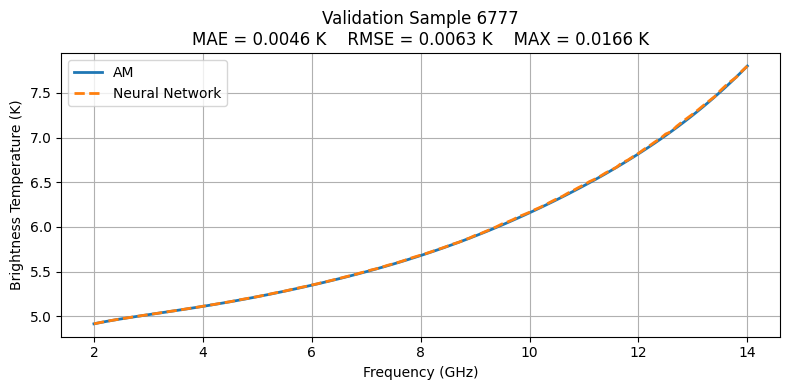

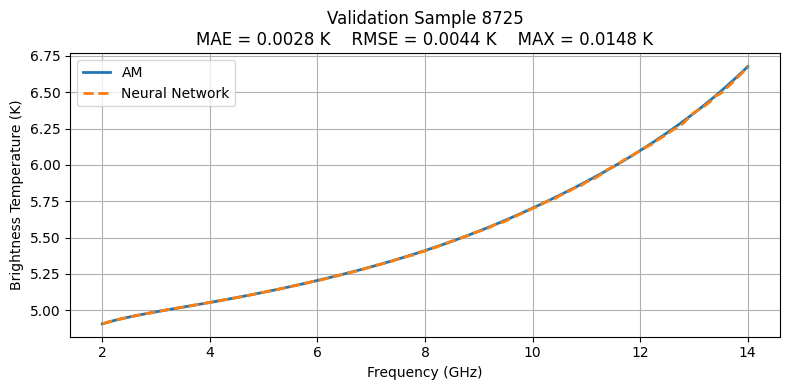

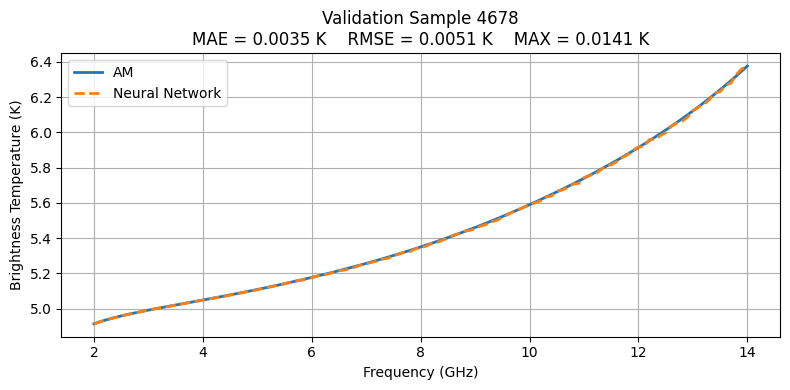

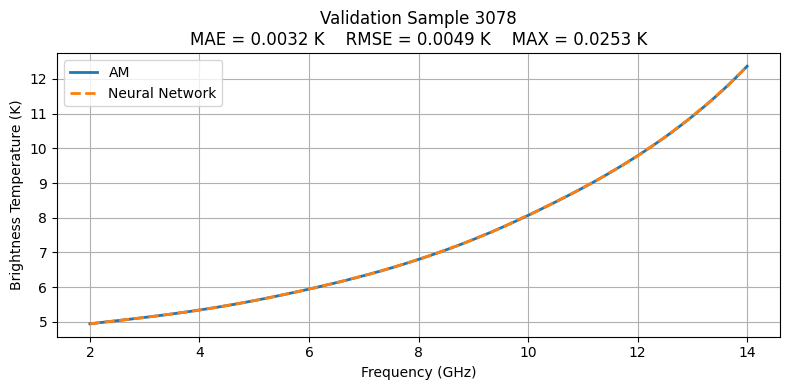

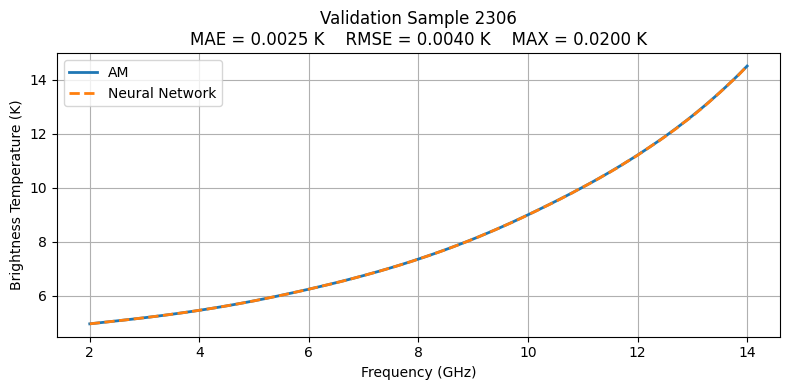

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SETTINGS
# ==========================================================

N_SAMPLES = 5

rng = np.random.default_rng(42)

indices = rng.choice(
    len(pred),
    size=N_SAMPLES,
    replace=False
)

# ==========================================================
# PLOT RANDOM SAMPLES
# ==========================================================

for n, idx in enumerate(indices):

    mae = sample_mae[idx]
    rmse = sample_rmse[idx]
    mx = sample_max[idx]

    plt.figure(figsize=(8,4))

    plt.plot(
        freq,
        truth[idx],
        lw=2,
        label="AM"
    )

    plt.plot(
        freq,
        pred[idx],
        "--",
        lw=2,
        label="Neural Network"
    )

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Brightness Temperature (K)")

    plt.title(
        f"Validation Sample {val_idx[idx]}\n"
        f"MAE = {mae:.4f} K    "
        f"RMSE = {rmse:.4f} K    "
        f"MAX = {mx:.4f} K"
    )

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

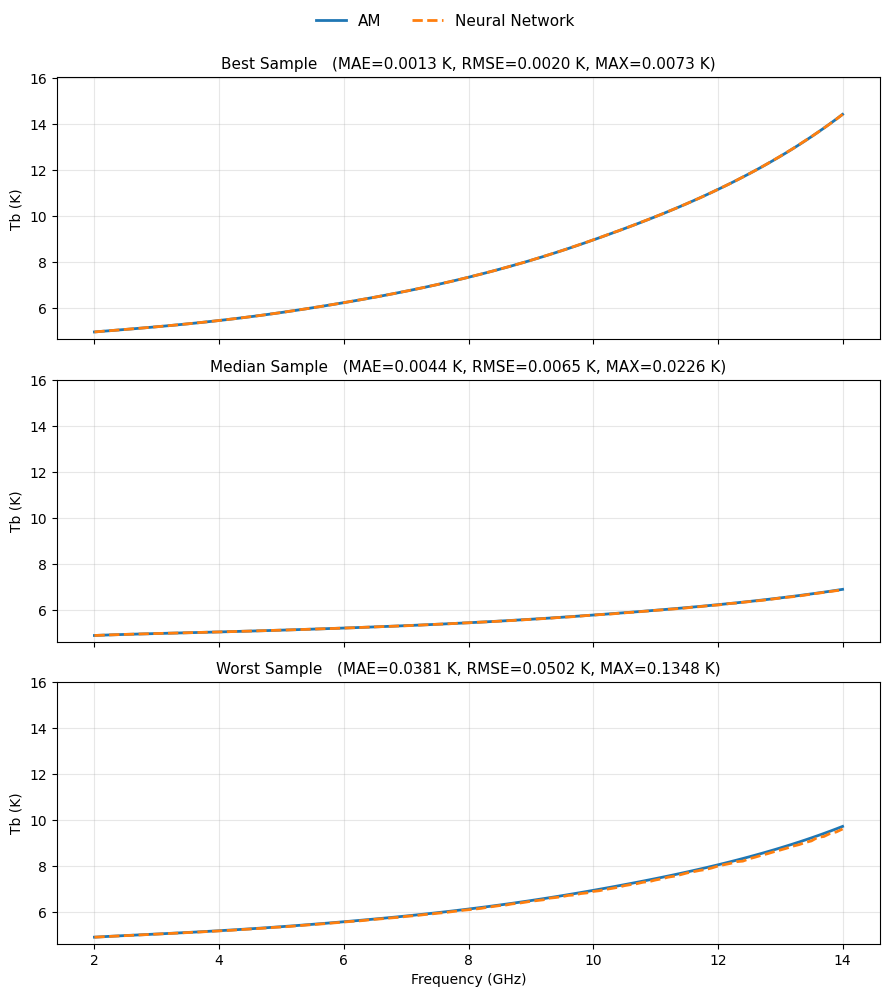

Case           Dataset Index           MAE          RMSE           MAX
Best                    7930      0.001326      0.002027      0.007349
Median                  5446      0.004379      0.006486      0.022608
Worst                   8982      0.038062      0.050223      0.134840


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FIND BEST / MEDIAN / WORST
# ==========================================================

best = np.argmin(sample_mae)
median = np.argsort(sample_mae)[len(sample_mae)//2]
worst = np.argmax(sample_mae)

cases = [
    ("Best", best),
    ("Median", median),
    ("Worst", worst),
]

# ==========================================================
# COMMON AXIS LIMITS
# ==========================================================

ymin = min(truth.min(), pred.min())
ymax = max(truth.max(), pred.max())

# small padding
pad = 0.02 * (ymax - ymin)
ymin -= pad
ymax += pad

# ==========================================================
# PLOT
# ==========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9,10),
    sharex=True,
    sharey=True
)

for ax, (name, idx) in zip(axes, cases):

    ax.plot(
        freq,
        truth[idx],
        lw=2,
        label="AM"
    )

    ax.plot(
        freq,
        pred[idx],
        "--",
        lw=2,
        label="Neural Network"
    )

    ax.set_title(
        f"{name} Sample   "
        f"(MAE={sample_mae[idx]:.4f} K, "
        f"RMSE={sample_rmse[idx]:.4f} K, "
        f"MAX={sample_max[idx]:.4f} K)",
        fontsize=11
    )

    ax.set_ylabel("Tb (K)")
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frequency (GHz)")

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

# ==========================================================
# PRINT SUMMARY
# ==========================================================

print("="*90)
print(f"{'Case':<10}{'Dataset Index':>18}{'MAE':>14}{'RMSE':>14}{'MAX':>14}")
print("="*90)

for name, idx in cases:

    print(
        f"{name:<10}"
        f"{val_idx[idx]:>18}"
        f"{sample_mae[idx]:>14.6f}"
        f"{sample_rmse[idx]:>14.6f}"
        f"{sample_max[idx]:>14.6f}"
    )

print("="*90)

Case                                 Index         MAE        RMSE         MAX
Highest Surface Pressure              8818     0.01043     0.01491     0.04173
Lowest Surface Pressure               2052     0.00453     0.00716     0.03720
Hottest Surface                       1017     0.00606     0.01090     0.05907
Coldest Surface                         79     0.00348     0.00563     0.02236
Highest Surface VMR                   9971     0.00303     0.00479     0.02489
Lowest Surface VMR                    4433     0.00883     0.01122     0.02740
Warmest Atmosphere                    2052     0.00453     0.00716     0.03720
Coldest Atmosphere                     923     0.00411     0.00594     0.02123
Wettest Atmosphere                    3850     0.00867     0.01061     0.02700
Driest Atmosphere                      153     0.00311     0.00481     0.01810


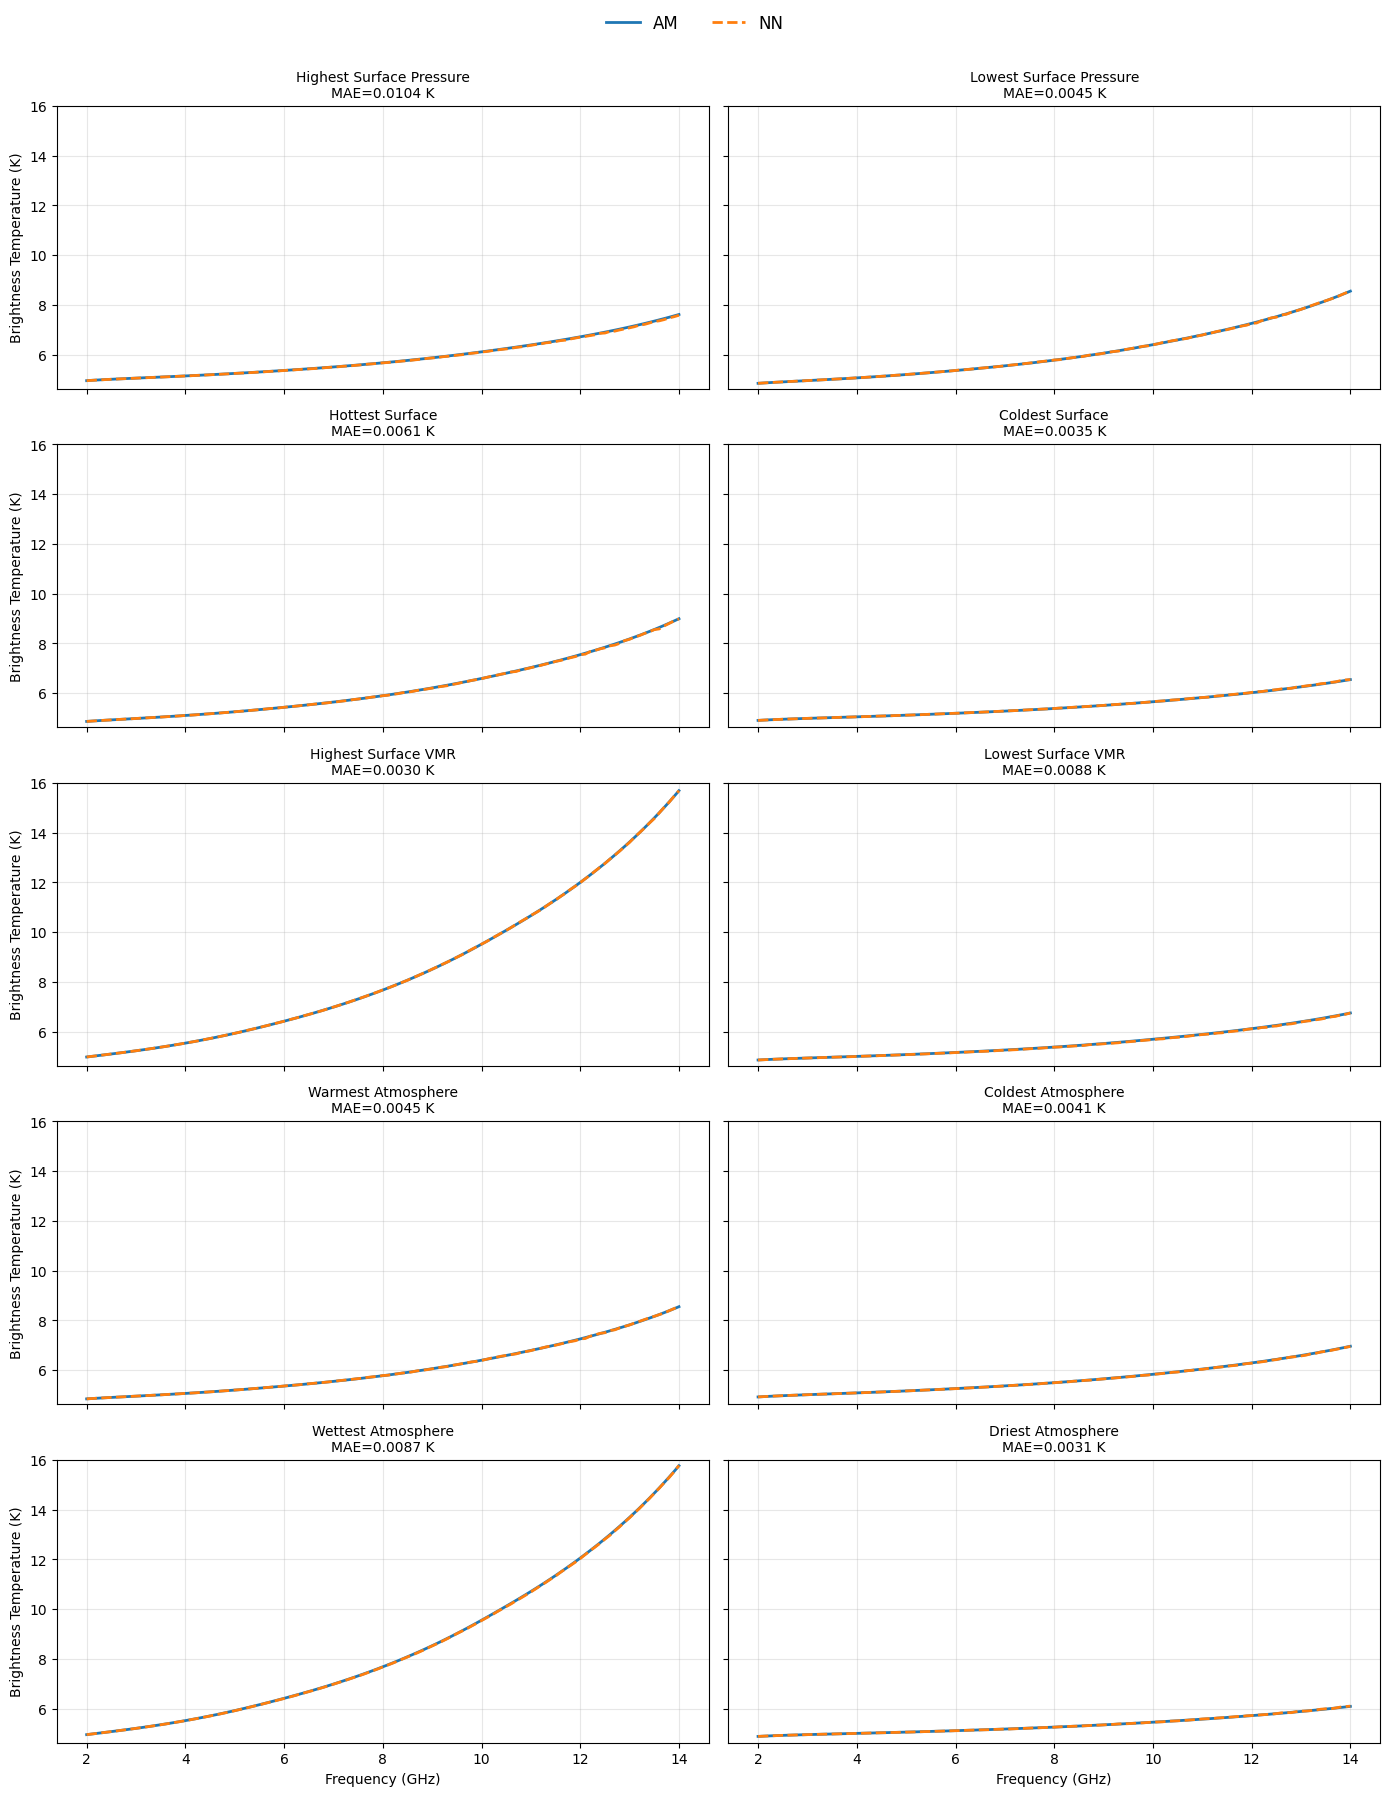

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FIND EXTREME CASES
# ==========================================================

cases = [
    ("Highest Surface Pressure", np.argmax(X[:,1])),
    ("Lowest Surface Pressure",  np.argmin(X[:,1])),

    ("Hottest Surface",          np.argmax(X[:,2])),
    ("Coldest Surface",          np.argmin(X[:,2])),

    ("Highest Surface VMR",      np.argmax(X[:,3])),
    ("Lowest Surface VMR",       np.argmin(X[:,3])),

    ("Warmest Atmosphere",       np.argmax(X[:,4:17].mean(axis=1))),
    ("Coldest Atmosphere",       np.argmin(X[:,4:17].mean(axis=1))),

    ("Wettest Atmosphere",       np.argmax(X[:,17:30].mean(axis=1))),
    ("Driest Atmosphere",        np.argmin(X[:,17:30].mean(axis=1))),
]

# ==========================================================
# COMMON Y LIMITS
# ==========================================================

ymin = min(truth.min(), pred.min())
ymax = max(truth.max(), pred.max())

pad = 0.02*(ymax-ymin)

ymin -= pad
ymax += pad

# ==========================================================
# FIGURE
# ==========================================================

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14,18),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

print("="*110)
print(
    f"{'Case':<32}"
    f"{'Index':>10}"
    f"{'MAE':>12}"
    f"{'RMSE':>12}"
    f"{'MAX':>12}"
)
print("="*110)

for ax, (title, idx) in zip(axes, cases):

    # prediction
    x = (X[idx]-X_mean)/X_std

    x = torch.tensor(
        x,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        tb_pred = model(x).cpu().numpy()[0]

    tb_pred = tb_pred*Y_std + Y_mean

    tb_true = Y[idx]

    err = tb_pred - tb_true

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mx = np.max(np.abs(err))

    print(
        f"{title:<32}"
        f"{idx:>10}"
        f"{mae:>12.5f}"
        f"{rmse:>12.5f}"
        f"{mx:>12.5f}"
    )

    ax.plot(
        freq,
        tb_true,
        lw=2,
        label="AM"
    )

    ax.plot(
        freq,
        tb_pred,
        "--",
        lw=2,
        label="NN"
    )

    ax.set_title(
        f"{title}\nMAE={mae:.4f} K",
        fontsize=10
    )

    ax.grid(alpha=0.3)
    ax.set_ylim(ymin,ymax)

print("="*110)

for ax in axes[-2:]:

    ax.set_xlabel("Frequency (GHz)")

for ax in axes[::2]:
    ax.set_ylabel("Brightness Temperature (K)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=12
)

plt.tight_layout(rect=[0,0,1,0.97])

plt.savefig(
    "Extreme_Atmosphere_Validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
import os
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import box, mapping

# ==========================================================
# PATHS
# ==========================================================

BASE = r"C:\Users\Darkrai\Projects\iitk proj"

SITE = os.path.join(
    BASE,
    "ERA5_DATABASE",
    "site_246536_727845"
)

DEM_PATH = os.path.join(
    BASE,
    "DEMs",
    "Mount Abu",
    "mount_abu_90.tif"          # <-- change if needed
)

# ==========================================================
# LOAD ERA5
# ==========================================================

pressure_ds = np.load(
    os.path.join(SITE, "pressure_2025.npz")
)

meta = np.load(
    os.path.join(SITE, "metadata_pressure.npz")
)

levels = meta["pressure_levels"] * 100

tile_lat = meta["tile_latitudes"]
tile_lon = meta["tile_longitudes"]

# ==========================================================
# CROP DEM
# ==========================================================

west  = float(tile_lon.min())
east  = float(tile_lon.max())

south = float(tile_lat.min())
north = float(tile_lat.max())

bbox = box(west, south, east, north)

with rasterio.open(DEM_PATH) as src:

    cropped_dem, cropped_transform = mask(
        src,
        [mapping(bbox)],
        crop=True
    )

cropped_dem = cropped_dem[0]

print("DEM shape:", cropped_dem.shape)
print("Pressure shape:", pressure_ds["temperature"].shape)

DEM shape: (1501, 1800)
Pressure shape: (8760, 13, 12, 12)


Surface height: (12, 12)
Sample 1 | t= 781 cell=(9,7) MAE=0.0561 RMSE=0.0765 MAX=0.2285
Sample 2 | t=3844 cell=(5,10) MAE=0.0849 RMSE=0.1131 MAX=0.3450
Sample 3 | t= 752 cell=(8,2) MAE=0.0093 RMSE=0.0128 MAX=0.0411
Sample 4 | t= 824 cell=(6,11) MAE=0.2177 RMSE=0.3004 MAX=0.8606
Sample 5 | t=6445 cell=(9,8) MAE=0.0408 RMSE=0.0624 MAX=0.2505
Sample 6 | t=6885 cell=(6,1) MAE=0.0137 RMSE=0.0192 MAX=0.0616


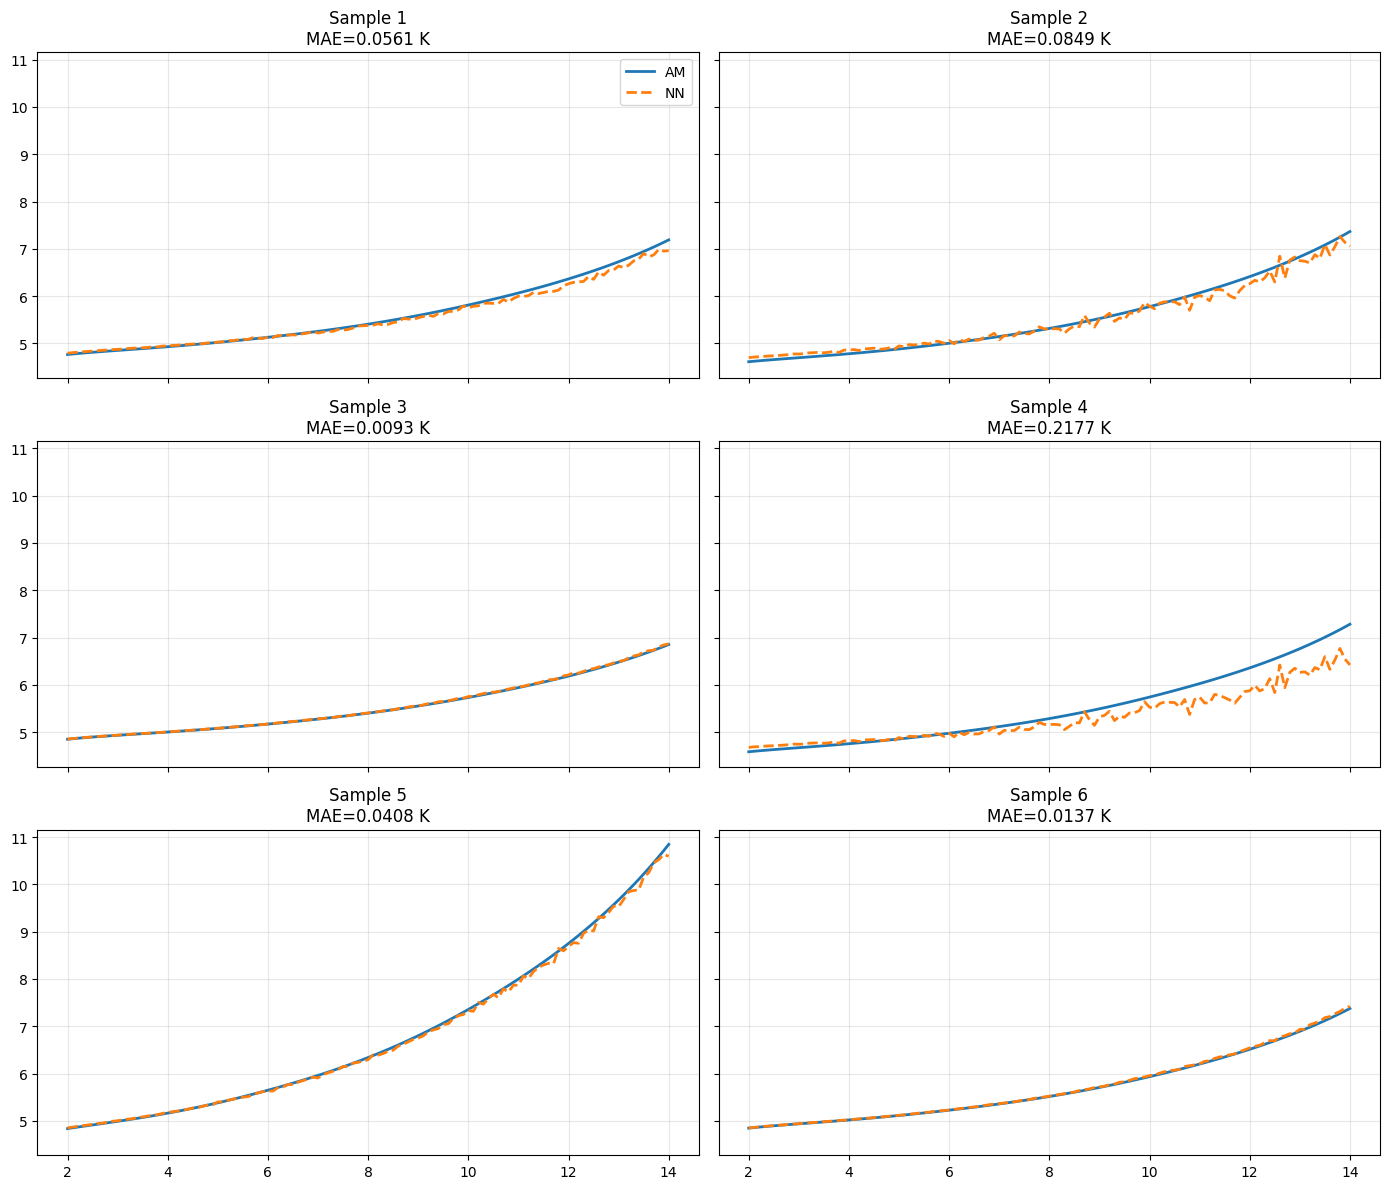


Mean MAE : 0.07041834
Median   : 0.04847537
Worst    : 0.21770865


In [34]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

# ==========================================================
# LOAD SITE
# ==========================================================

SITE = r"C:\Users\Darkrai\Projects\iitk proj\ERA5_DATABASE\site_246536_727845"

pressure_ds = np.load(os.path.join(SITE, "pressure_2025.npz"))
meta        = np.load(os.path.join(SITE, "metadata_pressure.npz"))

levels = meta["pressure_levels"] * 100.0

# ==========================================================
# DOWNSAMPLE DEM TO 12x12
# ==========================================================

H, W = cropped_dem.shape

ii = np.linspace(0, H-1, 12).astype(int)
jj = np.linspace(0, W-1, 12).astype(int)

surface_height = cropped_dem[np.ix_(ii, jj)]

print("Surface height:", surface_height.shape)

# ==========================================================
# CONSTANTS
# ==========================================================

g = 9.80665
epsilon = 0.622

# ==========================================================
# BUILD ATMOSPHERE
# ==========================================================

def build_row(t, i, j):

    T = pressure_ds["temperature"][t,:,i,j]
    q = pressure_ds["specific_humidity"][t,:,i,j]
    z = pressure_ds["geopotential"][t,:,i,j] / g

    vmr = q / (epsilon + (1-epsilon)*q)

    h = surface_height[i,j]

    insert = np.sum(z < h)
    insert = np.clip(insert, 1, len(levels)-1)

    pk  = np.log(levels[insert-1])
    pk1 = np.log(levels[insert])

    z0 = z[insert-1]
    z1 = z[insert]

    ratio = (h-z0)/(z1-z0)

    ps = np.exp(pk + ratio*(pk1-pk))
    ts = T[insert-1] + ratio*(T[insert]-T[insert-1])
    vs = vmr[insert-1] + ratio*(vmr[insert]-vmr[insert-1])

    row = np.empty(30, np.float32)

    row[0] = insert
    row[1] = np.round(ps/P_STEP)
    row[2] = np.round(ts/T_STEP)
    row[3] = np.round(vs/Q_STEP)

    row[4:17]  = np.round(T/T_STEP)
    row[17:30] = np.round(vmr/Q_STEP)

    return row

# ==========================================================
# RANDOM TESTS
# ==========================================================

rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14,12),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

maes = []

for k in range(6):

    t = rng.integers(pressure_ds["temperature"].shape[0])
    i = rng.integers(12)
    j = rng.integers(12)

    row = build_row(t,i,j)

    # -----------------------------
    # AM
    # -----------------------------

    freq, tau, tb_true = run_am(row)

    # -----------------------------
    # NN
    # -----------------------------

    x = (row - X_mean) / X_std

    x = torch.tensor(
        x,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        tb_pred = model(x).cpu().numpy()[0]

    tb_pred = tb_pred * Y_std + Y_mean

    # -----------------------------
    # Metrics
    # -----------------------------

    err = tb_pred - tb_true

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    mx = np.max(np.abs(err))

    maes.append(mae)

    print(
        f"Sample {k+1} | "
        f"t={t:4d} "
        f"cell=({i},{j}) "
        f"MAE={mae:.4f} "
        f"RMSE={rmse:.4f} "
        f"MAX={mx:.4f}"
    )

    axes[k].plot(
        freq,
        tb_true,
        lw=2,
        label="AM"
    )

    axes[k].plot(
        freq,
        tb_pred,
        "--",
        lw=2,
        label="NN"
    )

    axes[k].set_title(
        f"Sample {k+1}\nMAE={mae:.4f} K"
    )

    axes[k].grid(alpha=0.3)

axes[0].legend()

plt.tight_layout()

plt.show()

print("\n===================================================")
print("Mean MAE :", np.mean(maes))
print("Median   :", np.median(maes))
print("Worst    :", np.max(maes))
print("===================================================")